## Este notebook tiene como objetivo realizar el analisis EDA de los datos 

Importamos e instalamos las librerias necesarias

In [ ]:
%pip install seaborn matplotlib scikit-learn

In [2]:
%matplotlib inline 
import numpy as np 
import scipy as sp 
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.pyplot as plt
import pandas as pd 
#from pandas.tools.plotting import scatter_matrix
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
import string
import math
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import sklearn
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

Cargamos el train del split estratificado. No cargamos el test, solo se usará en la evaluación final del modelo.

In [4]:
train = pd.read_csv('../split-dataset/train/train-data.csv')

Ahora hechamos un vistazo al data para ver como viene formado y presentado

In [8]:
print(f"Shape: {train.shape}")  # (filas, columnas)
train.head()

train.info()

train.describe().T 

nulos = train.isnull().sum()
print(f"Total de nulos en el dataset: {nulos.sum()}")
print(f"Columnas con al menos un nulo: {(nulos > 0).sum()}")
print(f"Filas duplicadas: {train.duplicated().sum()}")

Shape: (5455, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0.493784,0.550153,0.544622,0.598524,0.598524,0.998980,0.797443,0.809355,0.303595,0.781616,6.780000e+09,0.000000e+00,0.466210,0.000432,0.196072,0.200919,0.200919,0.200919,0.221424,0.321214,0.030507,0.097956,0.176998,0.022238,0.848256,0.690475,0.690475,0.221159,7.200000e+09,0.000456,0.264398,0.380565,0.011323,0.005382,0.630702,0.002071,0.054479,0.945521,0.005227,0.369637,0.005780,0.097652,0.175145,0.397851,0.142429,0.002082,0.003039,1.264903e-04,0.000169,0.027419,0.015863,0.392958,0.013138,0.788318,0.146419,0.291350,0.007823,0.005575,0.000846,0.048699,0.352475,0.277522,0.015190,0.813360,0.733835,0.327756,0.000000,0.932937,0.002378,0.012305,7.670000e+09,3.780000e+09,0.593944,6.250000e+08,0.671568,0.452605,0.813360,0.327756,0.110933,0.635412,0.455924,0.586432,0.313704,0.025832,0,0.806631,0.001637,0.623661,0.598521,0.840649,0.276281,0.026814,0.565265,1,0.070742
1,0,0.534393,0.590765,0.573425,0.599302,0.599173,0.999023,0.797454,0.809359,0.303524,0.781621,3.520000e+09,0.000000e+00,0.465192,0.000321,0.255087,0.195946,0.195946,0.195946,0.249031,0.330268,0.138119,0.135412,0.206749,0.022206,0.848220,0.689580,0.689580,0.217614,7.250000e+08,0.000470,0.264301,0.383210,0.011338,0.009921,0.630861,0.010805,0.160474,0.839526,0.005774,0.375230,0.007560,0.135424,0.205822,0.414694,0.389805,0.000866,0.007305,4.209339e-04,0.001297

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5455 entries, 0 to 5454
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 5455 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  5455 non-null   float64
 2    ROA(A) before interest and % after tax                   5455 non-null   float64
 3    ROA(B) before interest and depreciation after tax        5455 non-null   float64
 4    Operating Gross Margin                                   5455 non-null   float64
 5    Realized Sales Gross Margin                              5455 non-null   float64
 6    Operating Profit Rate                                    5455 non-null   float64
 7    Pre-tax net Interest Rate                                5455 non-null   float64
 8    After-tax net Int

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,5455.0,0.032264,0.176717,0.000000,0.000000,0.000000,0.000000,1.000000
ROA(C) before interest and depreciation before interest,5455.0,0.504447,0.060354,0.024277,0.476113,0.502121,0.534612,1.000000
ROA(A) before interest and % after tax,5455.0,0.557818,0.065355,0.000000,0.535379,0.559365,0.587958,1.000000
ROA(B) before interest and depreciation after tax,5455.0,0.552946,0.061401,0.033514,0.527143,0.551689,0.582740,1.000000
Operating Gross Margin,5455.0,0.607765,0.017047,0.000000,0.600473,0.605983,0.613817,0.665151
...,...,...,...,...,...,...,...,...
Liability to Equity,5455.0,0.280410,0.013821,0.133503,0.276944,0.278779,0.281470,1.000000
Degree of Financial Leverage (DFL),5455.0,0.027642,0.017378,0.000000,0.026791,0.026809,0.026916,1.000000
Interest Coverage Ratio (Interest expense to EBIT),5455.0,0.565302,0.014320,0.000000,0.565158,0.565254,0.565732,1.000000
Net Income Flag,5455.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Total de nulos en el dataset: 0
Columnas con al menos un nulo: 0
Filas duplicadas: 0


Observaciones

Dataset: 5455 filas × 96 columnas (95 features + target).
Todas las columnas son numéricas (float64 / int64).
0 nulos, 0 duplicados, por lo tanto no se requiere imputación.

## Análisis de la variable objetivo `Bankrupt?`

Antes de mirar las features, analizamos el target por separado.

<Axes: xlabel='Bankrupt?', ylabel='count'>

Text(0.5, 1.0, 'Conteo absoluto')

Text(0.5, 0, 'Bankrupt? (0=No, 1=Sí)')

Text(0, 0.5, 'Número de empresas')

<Axes: xlabel='Bankrupt?'>

Text(0.5, 1.0, 'Proporción de clases')

Text(0.5, 0, 'Bankrupt? (0=No, 1=Sí)')

Text(0, 0.5, 'Proporción')

[Text(0, 0, '0 (No)'), Text(1, 0, '1 (Sí)')]

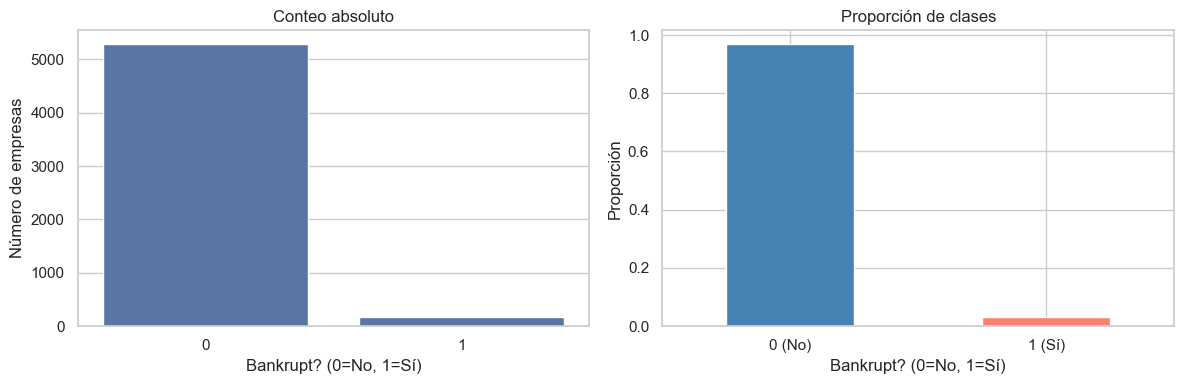

           Conteo  Porcentaje (%)
Bankrupt?                        
0            5279           96.77
1             176            3.23

Ratio de desbalance: 1 quiebra por cada 30.0 no-quiebras


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Conteo absoluto
sns.countplot(x='Bankrupt?', data=train, ax=ax[0])
ax[0].set_title('Conteo absoluto')
ax[0].set_xlabel('Bankrupt? (0=No, 1=Sí)')
ax[0].set_ylabel('Número de empresas')

# Proporción
proporciones = train['Bankrupt?'].value_counts(normalize=True).sort_index()
proporciones.plot(kind='bar', ax=ax[1], color=['steelblue', 'salmon'])
ax[1].set_title('Proporción de clases')
ax[1].set_xlabel('Bankrupt? (0=No, 1=Sí)')
ax[1].set_ylabel('Proporción')
ax[1].set_xticklabels(['0 (No)', '1 (Sí)'], rotation=0)

plt.tight_layout()
plt.show()

# Tabla resumen
conteo = train['Bankrupt?'].value_counts().sort_index()
porcentaje = train['Bankrupt?'].value_counts(normalize=True).sort_index() * 100
resumen = pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': porcentaje.round(2)})
print(resumen)
print(f"\nRatio de desbalance: 1 quiebra por cada {conteo[0] / conteo[1]:.1f} no-quiebras")

Observaciones

El 96.77% de las empresas no quiebran y solo el 3.23% sí, hay 1 quiebra por cada ~30 no-quiebras.
Es un desbalance fuerte pero es normal en este tipo de problemas, las quiebras son eventos raros en la realidad.
No vamos a generar datos sintéticos todavía, primero hay que ver cómo se comporta el modelo con los datos reales usando class_weight='balanced'.
Para evaluar no vamos a usar accuracy porque un modelo que siempre diga "no quiebra" sacaría más del 96%

## Análisis univariado de las features

Vemos cómo se distribuye cada feature por sí sola. Como tenemos 95 features, no las graficamos todas. Primero detectamos features constantes o casi constantes (varianza ~0, candidatas a eliminar) y después visualizamos las distribuciones de un grupo representativo usando el patrón grid + loop.

In [11]:
# Separamos target y features
X = train.drop(columns=['Bankrupt?'])
y = train['Bankrupt?']

# Top features con menor varianza
varianzas = X.var().sort_values()
print("Top 10 features con MENOR varianza:")
print(varianzas.head(10).to_string())

# Features completamente constantes
unicos = X.nunique()
constantes = unicos[unicos == 1].index.tolist()
print(f"\nFeatures con un único valor (constantes): {len(constantes)}")
for c in constantes:
    print(f"  - {c.strip()}")

Top 10 features con MENOR varianza:
Net Income Flag                            0.000000
Realized Sales Gross Profit Growth Rate    0.000005
Total Asset Return Growth Rate Ratio       0.000014
Cash Flow to Sales                         0.000024
Working capitcal Turnover Rate             0.000032
After-tax net Interest Rate                0.000110
Net Income to Stockholder's Equity         0.000117
Inventory/Working Capital                  0.000121
Continuous interest rate (after tax)       0.000123
Interest Expense Ratio                     0.000126

Features con un único valor (constantes): 1
  - Net Income Flag


In [ ]:
# Helper: encuentra el nombre exacto de una columna por substring
def col(keyword):
    matches = [c for c in train.columns if keyword.lower() in c.lower()]
    if len(matches) == 0:
        raise ValueError(f"No se encontró columna con '{keyword}'")
    return matches[0]

# Seleccionamos ~16 features de distintas "familias" para visualizar
# (no las 95, sería ilegible). El criterio es cubrir distintos tipos de
# indicador financiero: rentabilidad, márgenes, liquidez, endeudamiento, etc.
features_seleccionadas = [
    col('ROA(A)'),                            # rentabilidad sobre activos
    col('Operating Gross Margin'),            # márgenes
    col('Cash flow rate'),                    # cash flow
    col('Tax rate (A)'),                      # impuestos
    col('Net Value Per Share (A)'),           # valor por acción
    col('Operating Profit Growth Rate'),      # crecimiento
    col('Total Asset Growth Rate'),           # crecimiento de activos
    col('Current Ratio'),                     # liquidez
    col('Quick Ratio'),                       # liquidez
    col('Debt ratio %'),                      # endeudamiento
    col('Total Asset Turnover'),              # rotación
    col('Cash/Total Assets'),                 # liquidez (cash)
    col('Retained Earnings to Total Assets'), # rentabilidad acumulada
    col('Net Income to Total Assets'),        # rentabilidad neta
    col('Liability to Equity'),               # apalancamiento
    col('Equity to Liability'),               # apalancamiento (inverso)
]

print(f"Visualizando {len(features_seleccionadas)} features representativas")

Visualizando 16 features representativas


<Axes: xlabel=' ROA(A) before interest and % after tax', ylabel='Density'>

Text(0.5, 1.0, 'ROA(A) before interest and % after tax')

Text(0.5, 0, '')

<Axes: xlabel=' Operating Gross Margin', ylabel='Density'>

Text(0.5, 1.0, 'Operating Gross Margin')

...

Text(0.5, 0, '')

<Axes: xlabel=' Equity to Liability', ylabel='Density'>

Text(0.5, 1.0, 'Equity to Liability')

Text(0.5, 0, '')

Text(0.5, 1.0, 'Distribución (KDE) de features representativas')

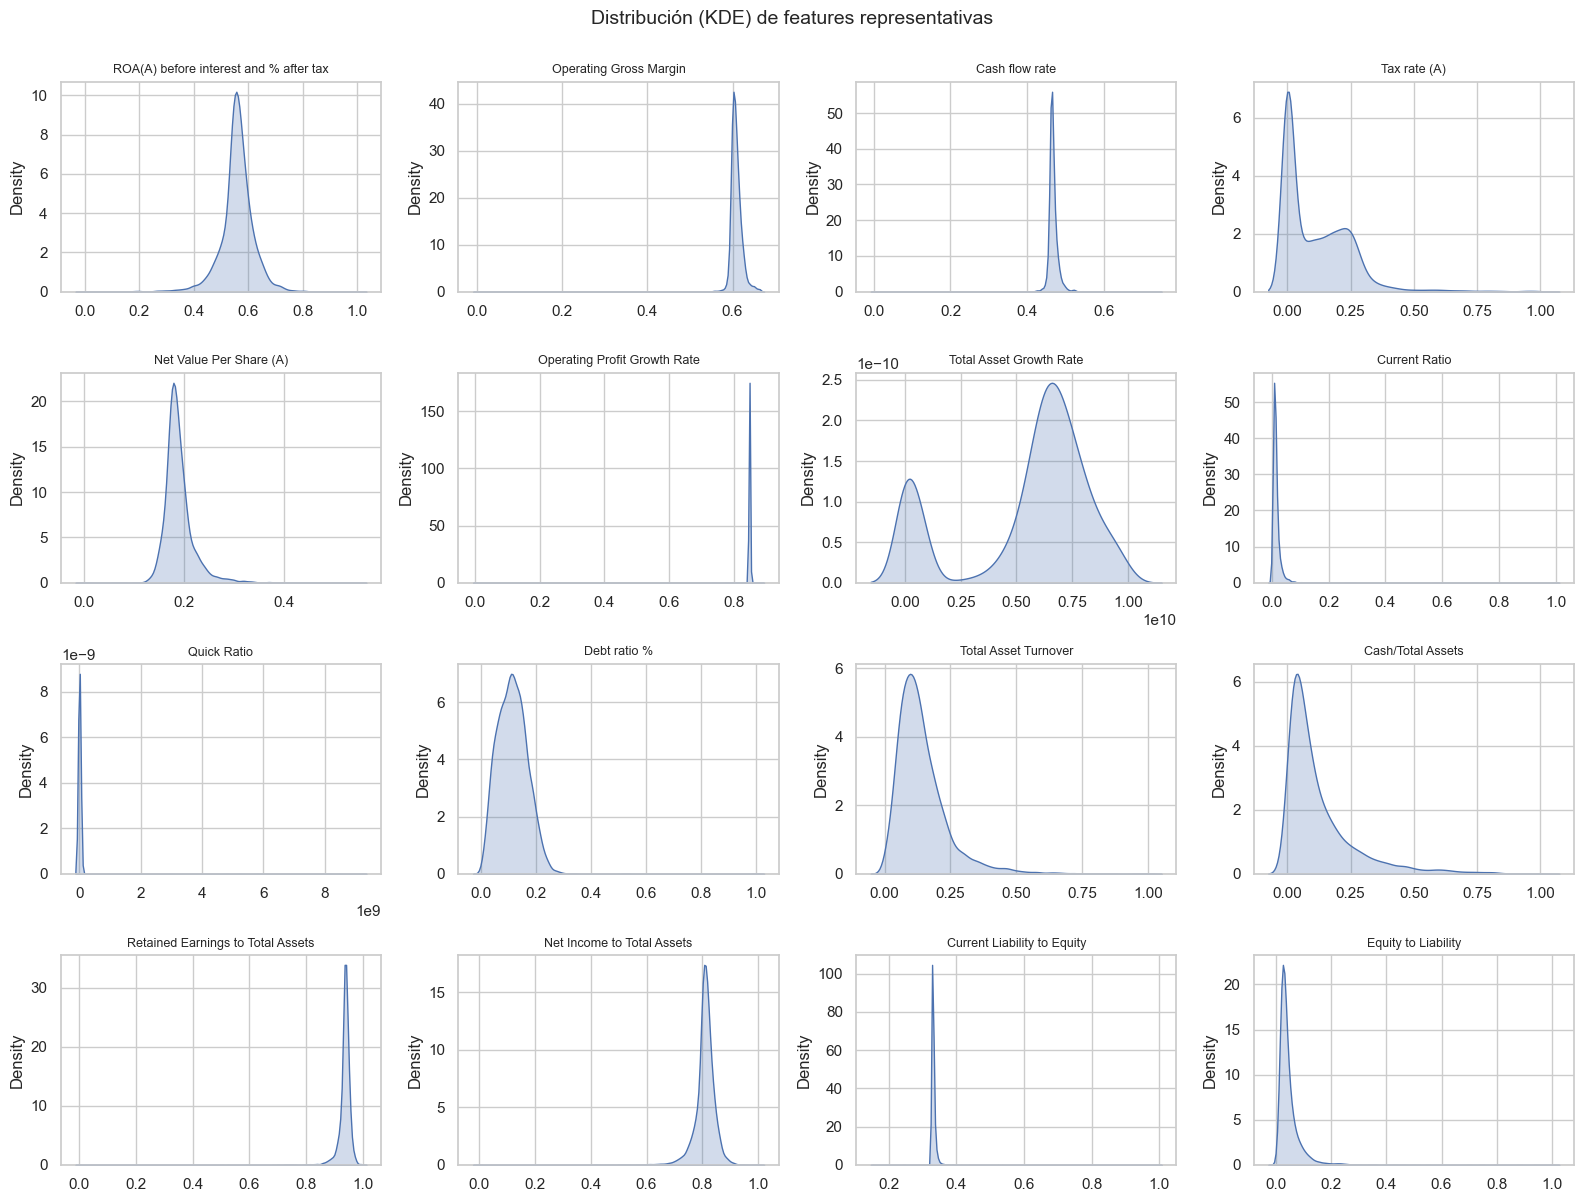

In [13]:
# Patrón grid + loop
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_seleccionadas):
    sns.kdeplot(data=train, x=feature, ax=axes[i], fill=True)
    axes[i].set_title(feature.strip(), fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Distribución (KDE) de features representativas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

<Axes: ylabel=' ROA(A) before interest and % after tax'>

Text(0.5, 1.0, 'ROA(A) before interest and % after tax')

Text(0, 0.5, '')

<Axes: ylabel=' Operating Gross Margin'>

Text(0.5, 1.0, 'Operating Gross Margin')

...

Text(0, 0.5, '')

<Axes: ylabel=' Equity to Liability'>

Text(0.5, 1.0, 'Equity to Liability')

Text(0, 0.5, '')

Text(0.5, 1.0, 'Boxplots de features representativas (detección de outliers)')

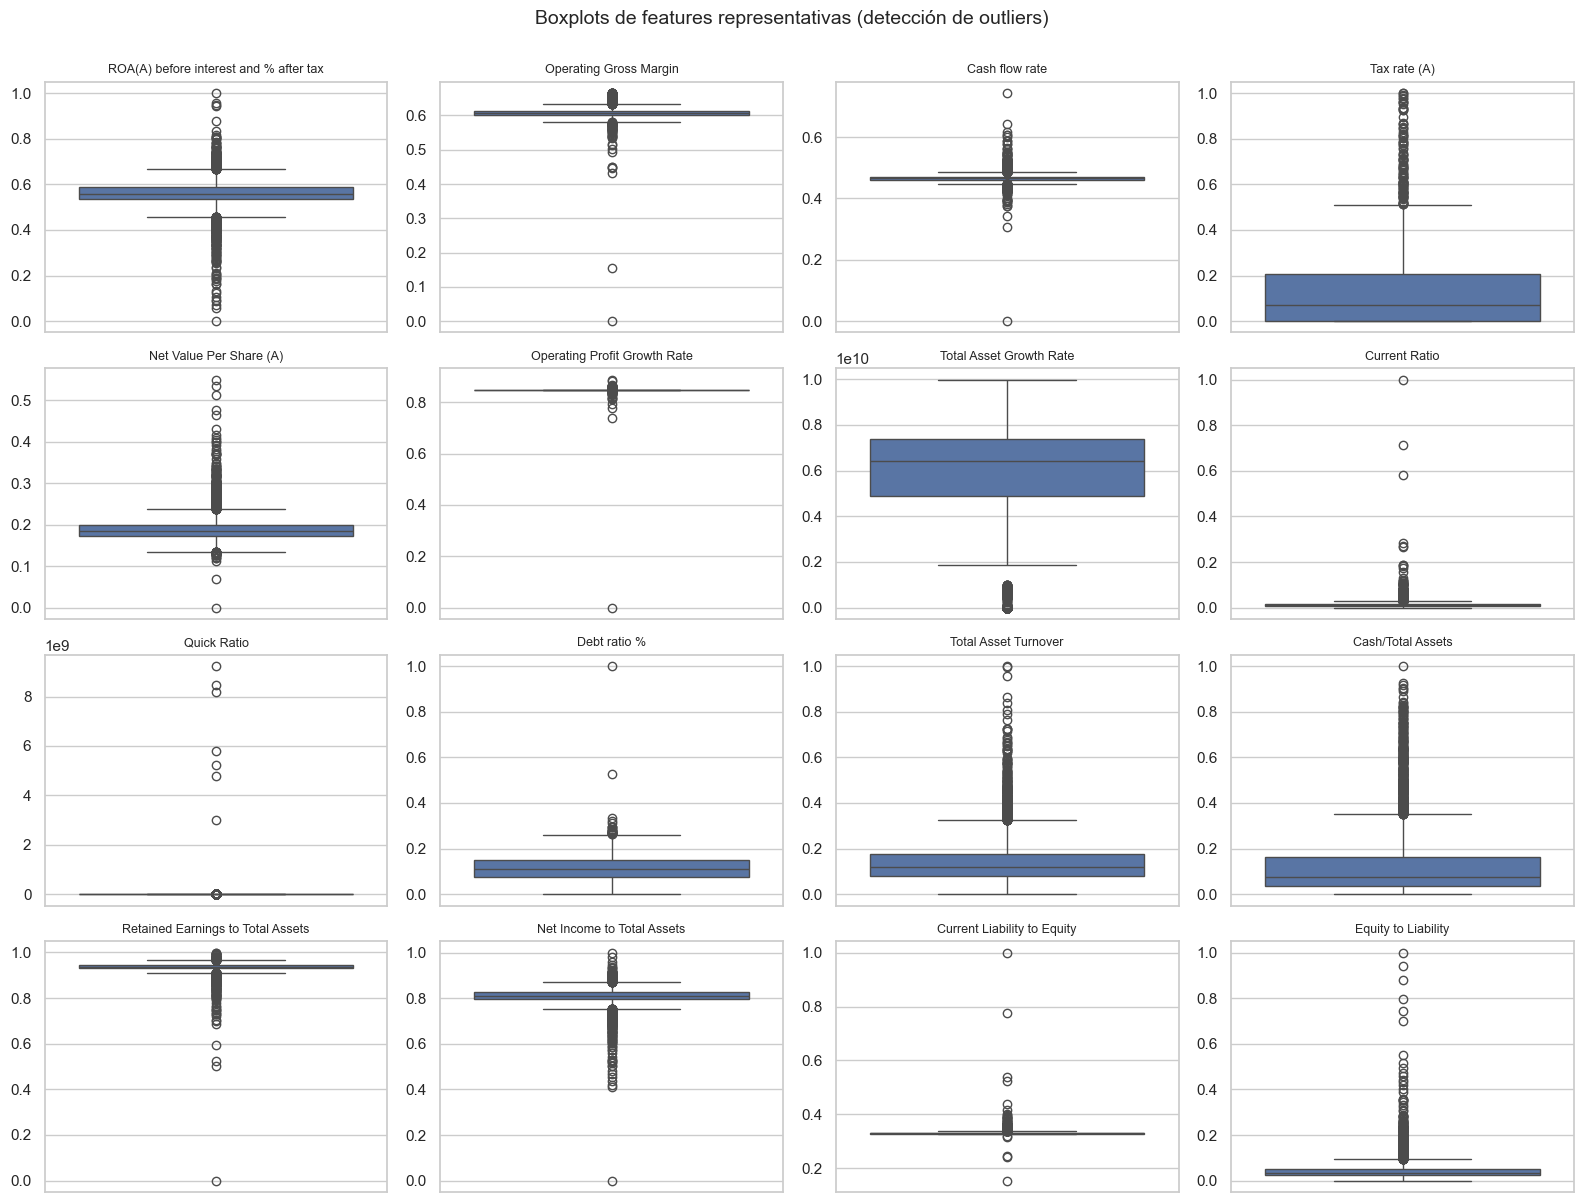

In [14]:
# Boxplots de las mismas features para detectar outliers
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_seleccionadas):
    sns.boxplot(data=train, y=feature, ax=axes[i])
    axes[i].set_title(feature.strip(), fontsize=9)
    axes[i].set_ylabel('')

plt.suptitle('Boxplots de features representativas (detección de outliers)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Observaciones
La única feature constante es Net Income Flag, hay que eliminarla.

Hay otras 9 features con varianza muy chica (Operating Profit Growth Rate, Operating Gross Margin, Cash flow rate, Current Liability to Equity, etc.) pero no las eliminamos manualmente, el modelo o PCA las descartarán solos si no aportan.

Confirmado que hay features con escalas explosivas (Quick Ratio hasta 1e9, Total Asset Growth Rate hasta 1e10), entonces sí necesitamos escalado en el pipeline.
Los boxplots muestran muchísimos outliers en casi todas las features, así que RobustScaler es mejor opción que StandardScaler

## Análisis bivariado: features vs target

Hasta ahora vimos cada cosa por separado. Acá cruzamos las features contra el target para ver cuáles ayudan a distinguir las empresas que quiebran de las que no.

Tres ángulos:
- **KDE superpuesto por clase**:si las dos distribuciones se separan, la feature tiene poder predictivo.
- **Boxplots por clase**: confirmación visual con medianas e IQR.
- **Ranking numérico**: diferencia de medias normalizada entre clases para las 95 features, no solo las 16 visualizadas.

<Axes: xlabel=' ROA(A) before interest and % after tax', ylabel='Density'>

<Axes: xlabel=' ROA(A) before interest and % after tax', ylabel='Density'>

Text(0.5, 1.0, 'ROA(A) before interest and % after tax')

Text(0.5, 0, '')

<Axes: xlabel=' Operating Gross Margin', ylabel='Density'>

...

<Axes: xlabel=' Equity to Liability', ylabel='Density'>

<Axes: xlabel=' Equity to Liability', ylabel='Density'>

Text(0.5, 1.0, 'Equity to Liability')

Text(0.5, 0, '')

Text(0.5, 1.0, 'KDE por clase (No quiebra vs Quiebra) - features representativas')

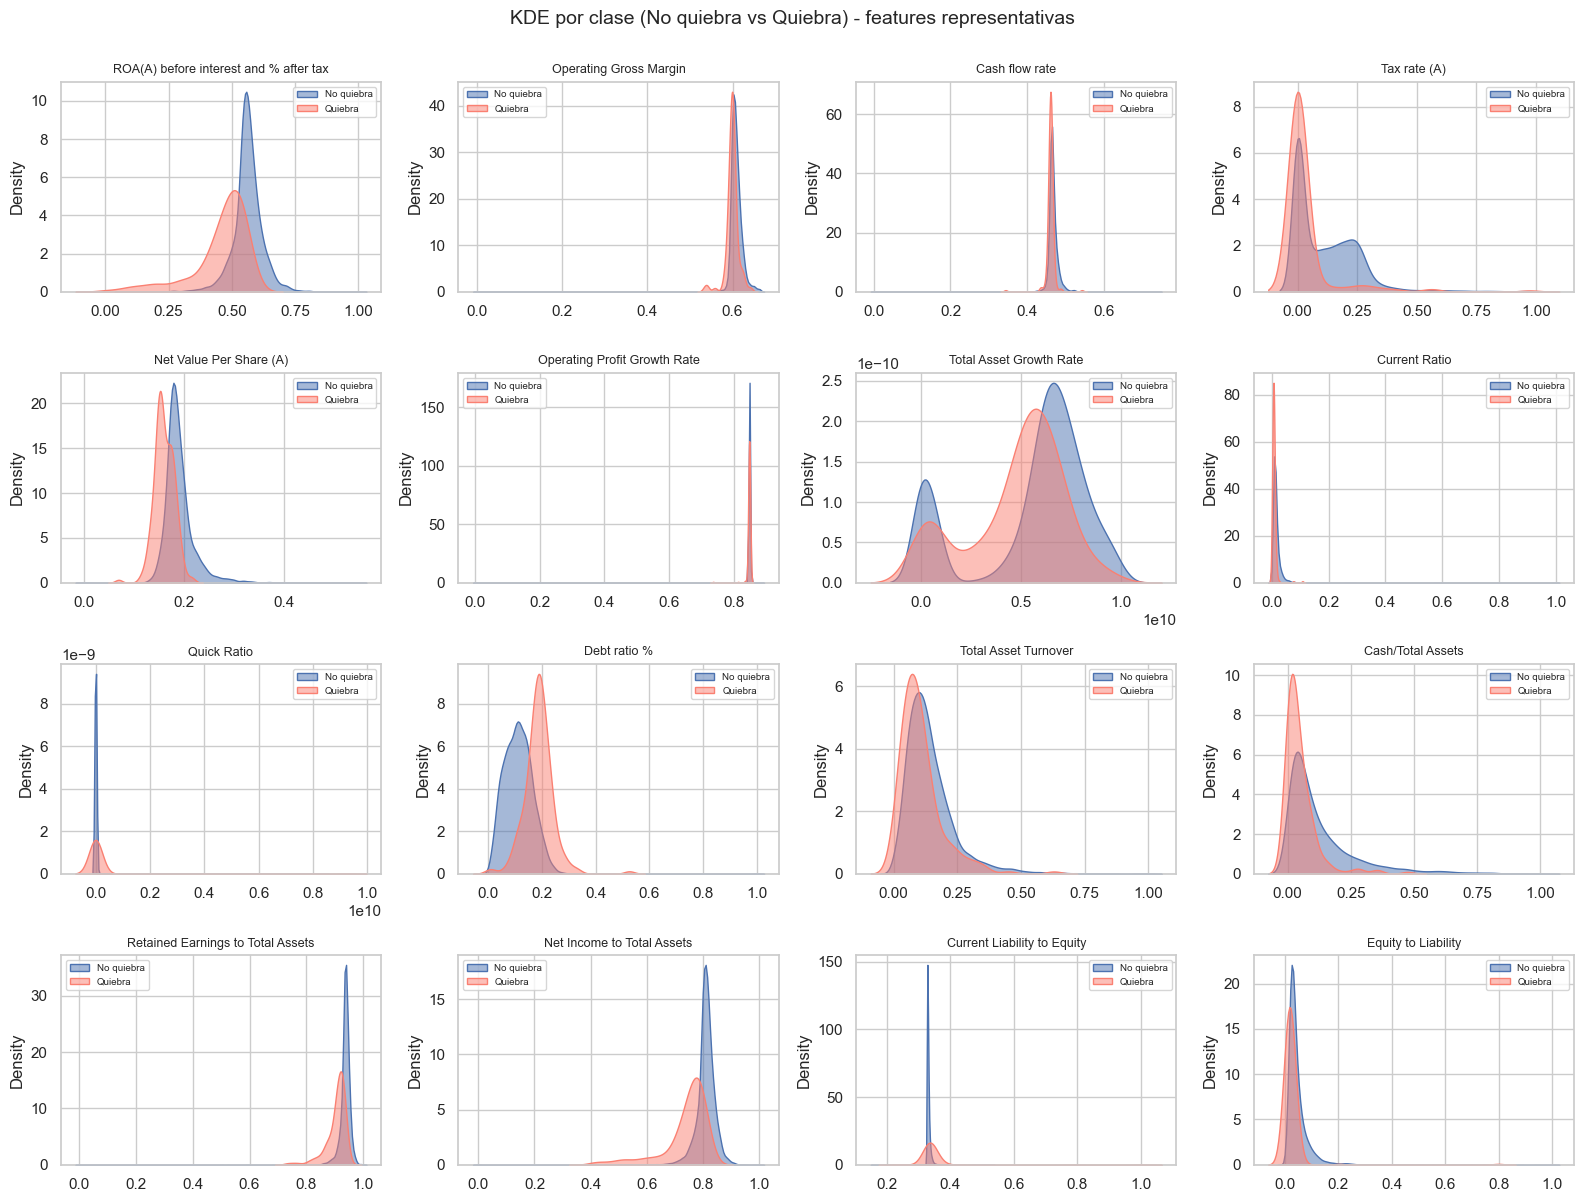

In [ ]:
# KDE superpuesto por clase: dos distribuciones en el mismo eje, una por clase.
# Si las dos curvas se separan visiblemente, la feature ayuda a distinguir
# quiebras de no-quiebras.

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_seleccionadas):
    sns.kdeplot(
        data=train[train['Bankrupt?'] == 0], x=feature, ax=axes[i],
        fill=True, label='No quiebra', alpha=0.5
    )
    sns.kdeplot(
        data=train[train['Bankrupt?'] == 1], x=feature, ax=axes[i],
        fill=True, label='Quiebra', alpha=0.5, color='salmon'
    )
    axes[i].set_title(feature.strip(), fontsize=9)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)

plt.suptitle('KDE por clase (No quiebra vs Quiebra) - features representativas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

<Axes: xlabel='Bankrupt?', ylabel=' ROA(A) before interest and % after tax'>

Text(0.5, 1.0, 'ROA(A) before interest and % after tax')

Text(0.5, 0, '')

<Axes: xlabel='Bankrupt?', ylabel=' Operating Gross Margin'>

Text(0.5, 1.0, 'Operating Gross Margin')

...

Text(0.5, 0, '')

<Axes: xlabel='Bankrupt?', ylabel=' Equity to Liability'>

Text(0.5, 1.0, 'Equity to Liability')

Text(0.5, 0, '')

Text(0.5, 1.0, 'Boxplots por clase (0 = No quiebra, 1 = Quiebra)')

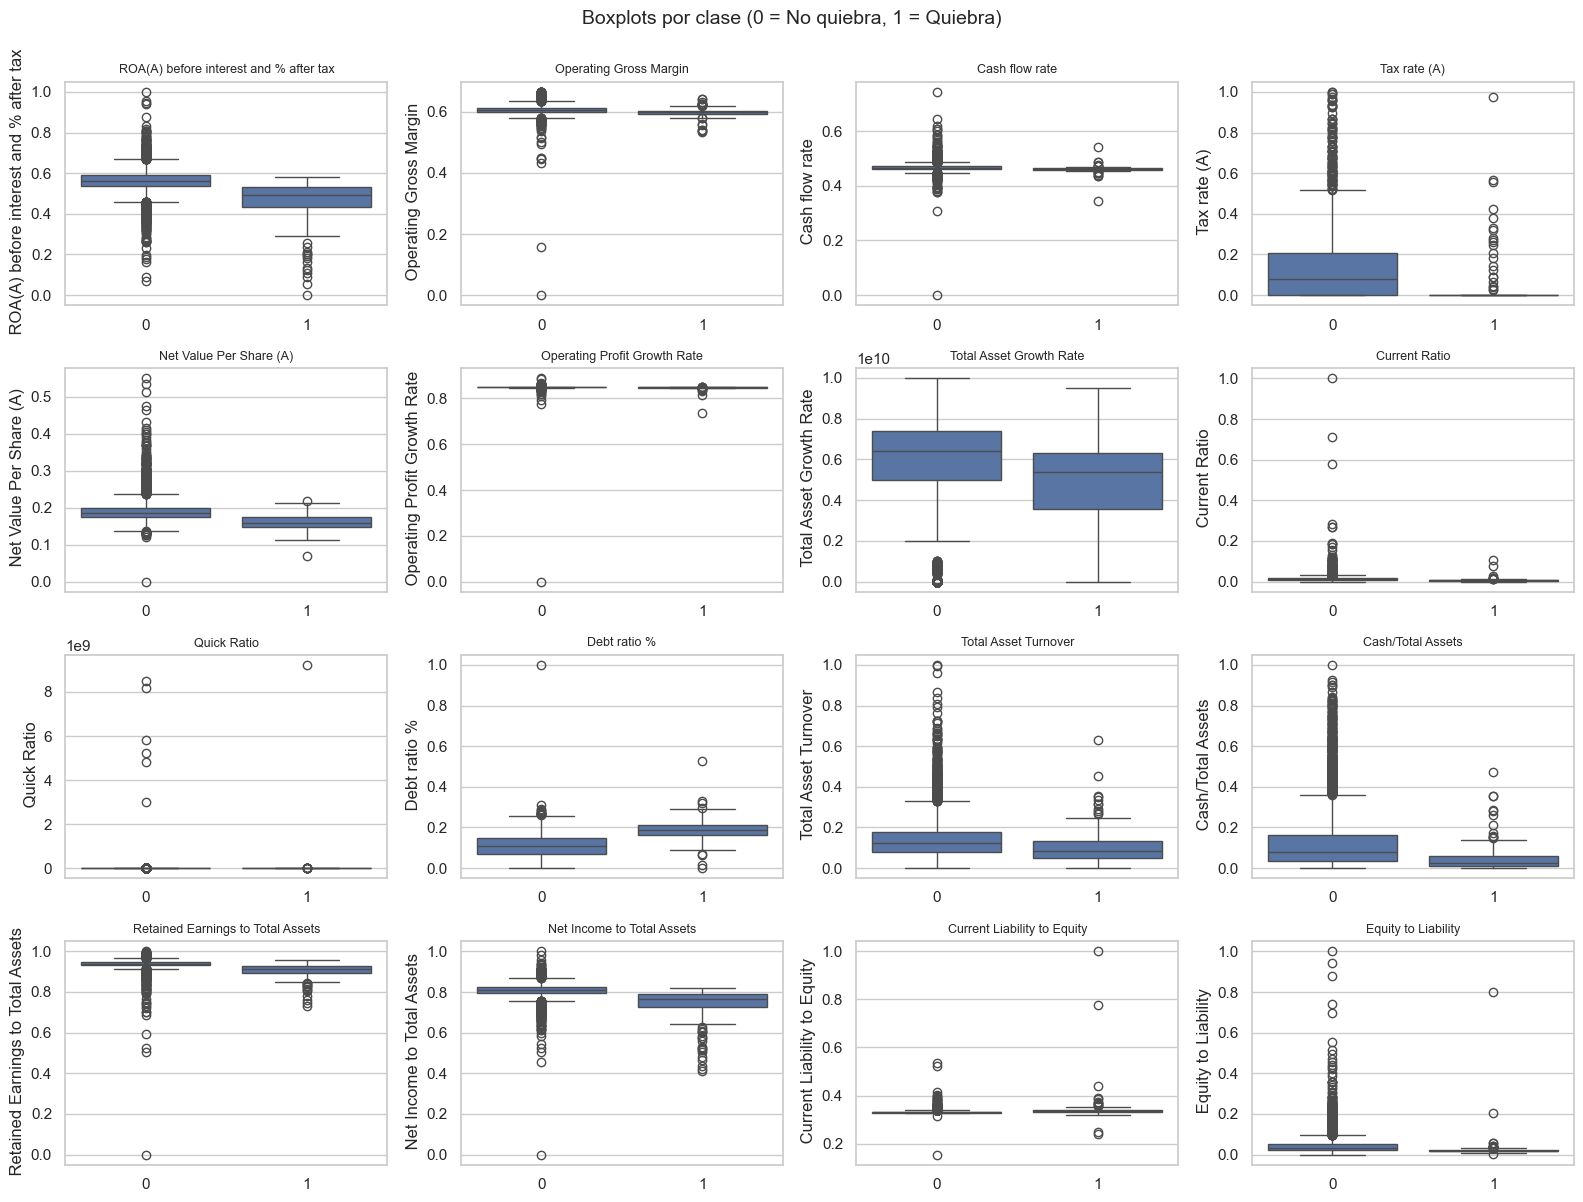

In [16]:
# Boxplots por clase: ¿hay diferencia de mediana entre quiebra/no-quiebra?
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_seleccionadas):
    sns.boxplot(data=train, x='Bankrupt?', y=feature, ax=axes[i])
    axes[i].set_title(feature.strip(), fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots por clase (0 = No quiebra, 1 = Quiebra)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# ¿qué features separan mejor a las dos clases?
# Calculamos la diferencia de medias entre clases, normalizada por la std de la feature

medias_por_clase = X.groupby(y).mean().T
medias_por_clase.columns = ['No_quiebra', 'Quiebra']
medias_por_clase['diferencia_abs'] = (
    medias_por_clase['Quiebra'] - medias_por_clase['No_quiebra']
).abs()
medias_por_clase['diferencia_normalizada'] = (
    medias_por_clase['diferencia_abs'] / X.std()
)

top20 = medias_por_clase.sort_values(
    'diferencia_normalizada', ascending=False
).head(20)

print("Top 20 features con mayor diferencia entre clases (normalizada):\n")
print(top20[['No_quiebra', 'Quiebra', 'diferencia_normalizada']].round(4).to_string())

Top 20 features con mayor diferencia entre clases (normalizada):

                                                         No_quiebra  Quiebra  diferencia_normalizada
Net Income to Total Assets                                   0.8097   0.7382                  1.7902
ROA(A) before interest and % after tax                       0.5612   0.4562                  1.6060
ROA(B) before interest and depreciation after tax            0.5560   0.4604                  1.5574
ROA(C) before interest and depreciation before interest      0.5073   0.4176                  1.4864
Debt ratio %                                                 0.1108   0.1868                  1.4014
Net worth/Assets                                             0.8892   0.8132                  1.4014
Persistent EPS in the Last Four Seasons                      0.2296   0.1897                  1.2506
Retained Earnings to Total Assets                            0.9355   0.9039                  1.2101
Net Income to Stockholder

Observaciones

Las features que más separan a las dos clases son las de rentabilidad (Net Income to Total Assets, ROA(A), ROA(B), ROA(C)) y las de endeudamiento (Debt ratio %, Net worth/Assets, Borrowing dependency). Tiene sentido: empresas menos rentables y más endeudadas son las que quiebran.

Hay redundancia obvia, los 4 ROAs miden básicamente lo mismo. Esto confirma que necesitamos PCA o feature selection en el pipeline.

Varias features (Operating Gross Margin, Cash flow rate, Current Ratio, Equity to Liability) muestran las dos clases pegadas en el KDE, no aportan al modelo.

## Análisis multivariado: correlación entre features

En la sección anterior vimos que las variantes de ROA dan resultados casi idénticos. Acá lo confirmamos numéricamente. Si muchas features están muy correlacionadas entre sí, no hace falta que el modelo las use todas — es información redundante que se puede comprimir con PCA o eliminar con feature selection.

Dos pasos:
- **Heatmap 95×95** para ver patrones generales (bloques de features correlacionadas entre sí).
- **Lista de pares con |correlación| > 0.9** para identificar redundancias concretas.

<Figure size 1800x1400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Matriz de correlación entre features (95×95)')

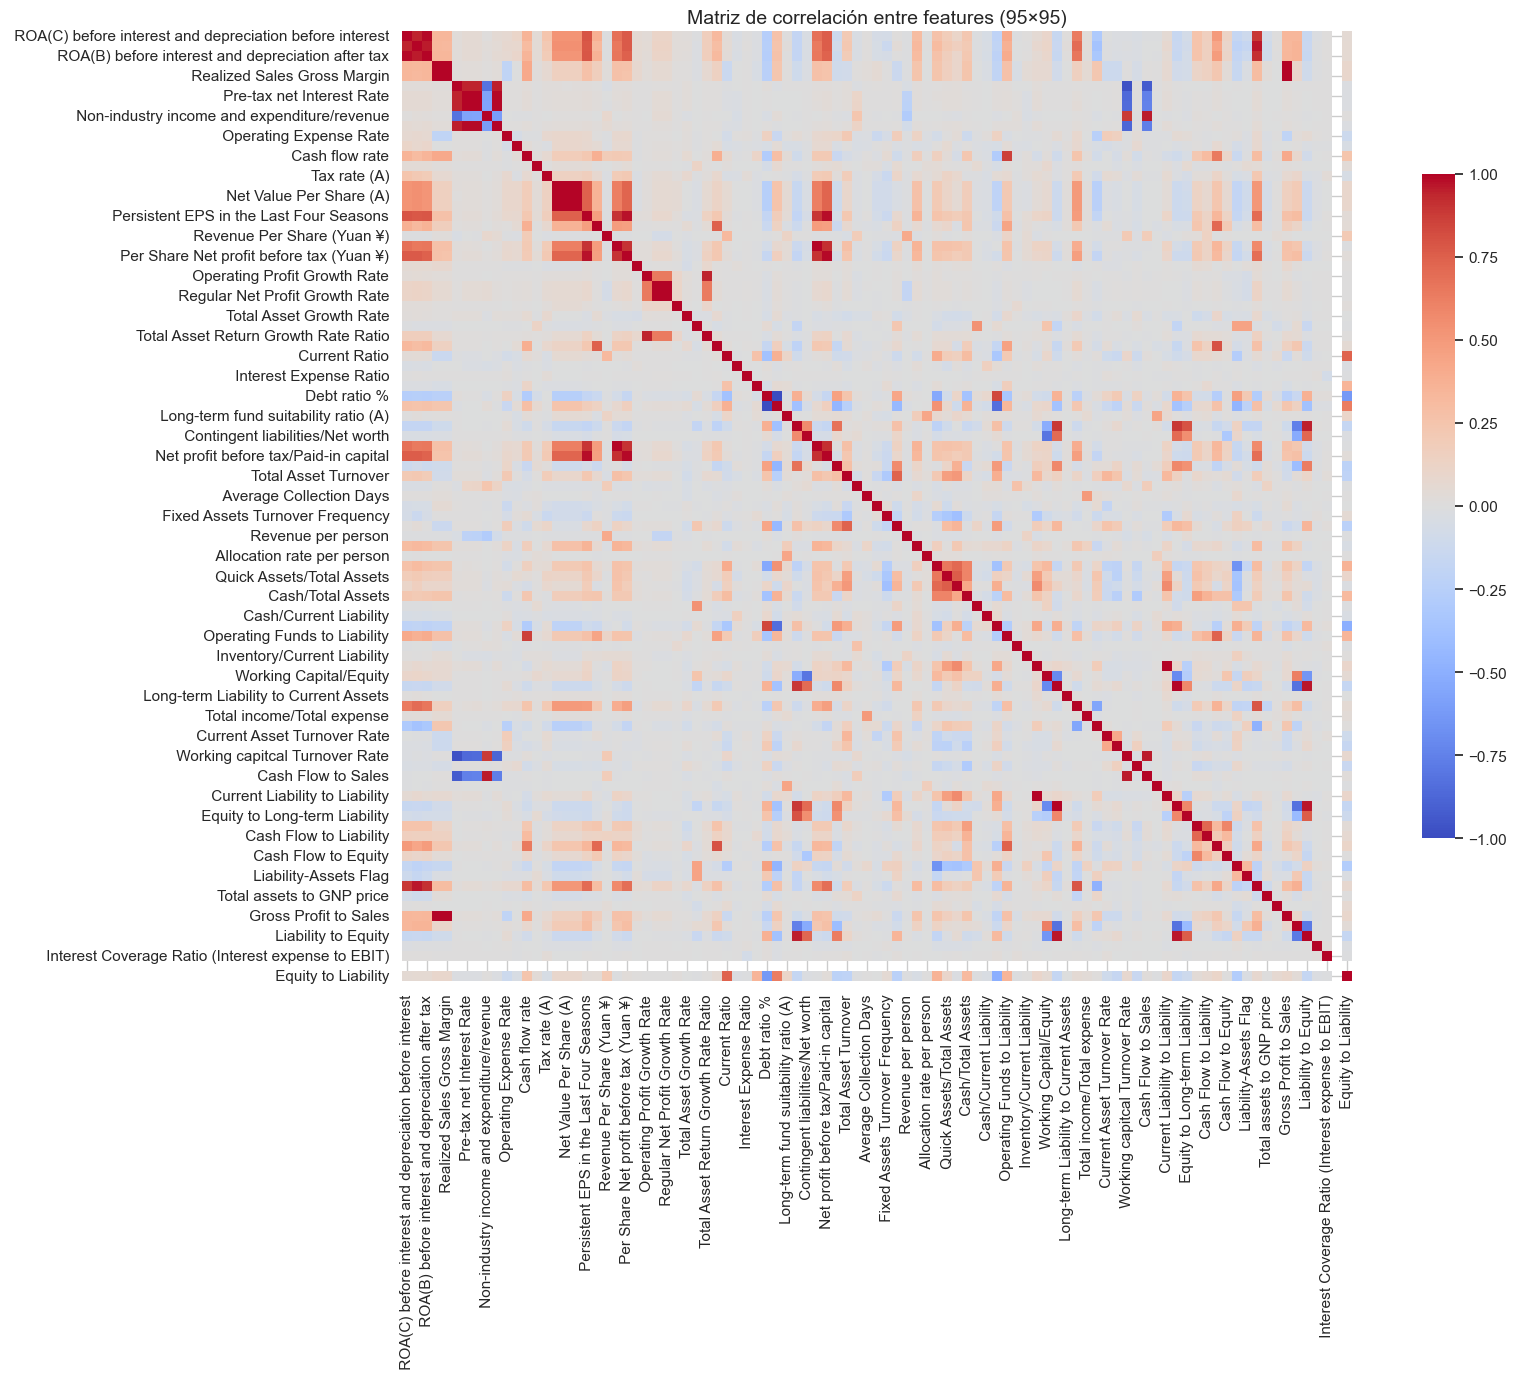

In [19]:
# Matriz de correlación de Pearson entre las 95 features.
# Sin annot porque 95x95 sería ilegible; vamos al color para ver patrones
# y luego sacamos los pares más correlacionados numéricamente.

corr = X.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.7})
plt.title('Matriz de correlación entre features (95×95)', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Pares de features con correlación absoluta > 0.9 (multicolinealidad fuerte).
# Tomamos solo el triángulo superior para no duplicar pares ni incluir la
# diagonal (correlación de una feature consigo misma = 1).

corr_abs = corr.abs()
mascara_triangulo = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
upper = corr_abs.where(mascara_triangulo)

threshold = 0.9
pares = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlacion'})
)
pares = pares[pares['Correlacion'] > threshold].sort_values('Correlacion', ascending=False)

print(f"Pares con |correlación| > {threshold}: {len(pares)}\n")
# Strip de nombres para que se lean bien en pantalla
pares['Feature_1'] = pares['Feature_1'].str.strip()
pares['Feature_2'] = pares['Feature_2'].str.strip()
print(pares.head(30).to_string(index=False))

Pares con |correlación| > 0.9: 36

                                              Feature_1                                         Feature_2  Correlacion
                             Current Liabilities/Equity                       Current Liability to Equity     1.000000
                          Current Liabilities/Liability                    Current Liability to Liability     1.000000
                                           Debt ratio %                                  Net worth/Assets     1.000000
                                 Operating Gross Margin                             Gross Profit to Sales     1.000000
                                Net Value Per Share (A)                           Net Value Per Share (C)     0.999862
                              Pre-tax net Interest Rate                       After-tax net Interest Rate     0.999834
                                Net Value Per Share (B)                           Net Value Per Share (A)     0.999769
             

Observaciones

Hay 36 pares de features con correlación absoluta mayor a 0.9, confirmamos que la multicolinealidad es brutal.

Los pares más extremos (correlación ~1.0) son básicamente la misma feature con nombres distintos: Current Liabilities/Equity = Current Liability to Equity, Debt ratio % es el complemento de Net worth/Assets, Operating Gross Margin = Gross Profit to Sales.

Las familias más redundantes son los ROAs (A, B, C), los Net Value Per Share (A, B, C), los Interest Rates (Pre-tax, After-tax, Continuous), y los Gross Margin.
Esto justifica usar PCA en el pipeline para reducir las 95 features sin perder información.

## Conclusiones del EDA

Cierre del análisis exploratorio.

### Resumen de hallazgos

El dataset trae 5455 empresas con 95 features financieras y un target binario (`Bankrupt?`). No hay nulos ni duplicados.

El target está fuertemente desbalanceado: el 96.77% de las empresas no quiebran y solo el 3.23% sí, es decir, 1 quiebra por cada ~30 no-quiebras. Es un desbalance real y esperable para este tipo de problema.

De las 95 features, solo una es constante: `Net Income Flag`. Hay otras 9 con varianza muy chica pero no son constantes, las dejamos.

Las features más predictivas (mayor diferencia entre clases) son las de rentabilidad (Net Income to Total Assets, ROA(A), ROA(B), ROA(C)) y las de endeudamiento (Debt ratio %, Net worth/Assets, Borrowing dependency). Esto tiene sentido económico: empresas menos rentables y más endeudadas son las que quiebran.

Hay 36 pares de features con correlación absoluta mayor a 0.9.

### Decisiones para el pipeline

Eliminar manualmente la columna `Net Income Flag` antes de entrenar (es constante, no aporta).

Usar `RobustScaler` para escalar las features. Es mejor que `StandardScaler` porque hay muchos outliers, y RobustScaler usa mediana e IQR en vez de media y std, por lo que no se deja arrastrar por valores extremos.

Usar PCA para reducir las dimensiones. Con la multicolinealidad que vimos, probablemente con 20-25 componentes se conserve más del 95% de la varianza.

Manejar el desbalance con `class_weight='balanced'` en los modelos. No vamos a generar datos sintéticos por ahora.

Evaluar con PR-AUC, recall, F1 y matriz de confusión. No usar accuracy porque con el desbalance que hay, un modelo que siempre diga "no quiebra" sacaría más del 96%.